## Preliminary Evolutionary Experiments
Can you evolve fw and bw walkers then identify a pair that has fairly similar average activity levels, and then hand-design (numerically) an HP mechanism that's centered around both of them and test its performance in the vicinity of both


In [2]:
import matplotlib.pyplot as plt
import numpy as np

Start off by assuming that all evolutions succeeded, and if it identifies one that is bad, I'll throw it out manually. since my data saving didn't work

In [49]:
#forward walkers
avg_vals_forward = np.zeros((100,2))
for i in range(100):
    traj = np.loadtxt("./Forward Walkers/%s/trajectory.dat" % i)
    left = 0
    returned = 0
    avg = np.zeros(2)
    j = 0
    while not returned and j < len(traj):
        dist = np.linalg.norm(traj[j] - traj[0])
        avg += traj[j]
        if dist > 0.015 and left==0:
            left = 1
        if dist < 0.015 and left==1:
            returned = 1
            break
        j += 1
    if j == len(traj):
        if not left:
            print("%s never left" % i)
        else:
            print("%s never returned" % i)
    avg = avg/j
    if returned:
        avg_vals_forward[i] = avg


46 never left
49 never left
70 never left


In [50]:
avg_vals_backward = np.zeros((100,2))
for i in range(100):
    traj = np.loadtxt("./Backward Walkers/%s/trajectory.dat" % i)
    left = 0
    returned = 0
    avg = np.zeros(2)
    j = 0
    while not returned and j < len(traj):
        dist = np.linalg.norm(traj[j] - traj[0])
        avg += traj[j]
        if dist > 0.015 and left==0:
            left = 1
        if dist < 0.015 and left==1:
            returned = 1
            break
        j += 1
    if j == len(traj):
        if not left:
            print("%s never left" % i)
        else:
            print("%s never returned" % i)
    avg = avg/j
    if returned:
        avg_vals_backward[i] = avg

13 never returned
15 never returned
19 never returned
21 never returned
22 never returned
23 never returned
29 never returned
34 never returned
42 never left
45 never returned
47 never returned
54 never returned
59 never returned
63 never returned
72 never returned
87 never left
93 never returned


In [51]:
avg_vals_forward = avg_vals_forward[avg_vals_forward[:,0]!=0]
avg_vals_backward = avg_vals_backward[avg_vals_backward[:,0]!=0]   

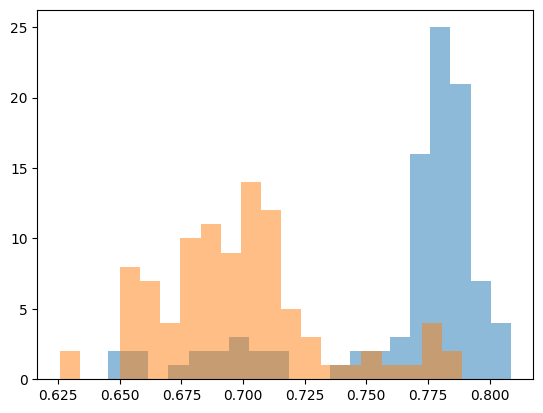

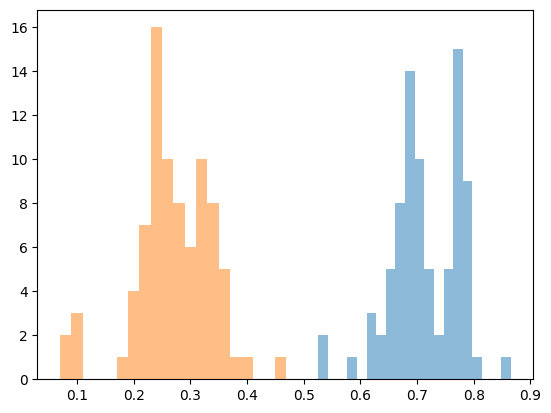

In [52]:
plt.hist(avg_vals_forward[:,0], bins=20, alpha=0.5, label='Forward Walkers, N1')
plt.hist(avg_vals_forward[:,1], bins=20, alpha=0.5, label='Forward Walkers, N2')
plt.show()
plt.hist(avg_vals_backward[:,0], bins=20, alpha=0.5, label='Backward Walkers,N1')
plt.hist(avg_vals_backward[:,1], bins=20, alpha=0.5, label='Backward Walkers,N2')
plt.show()


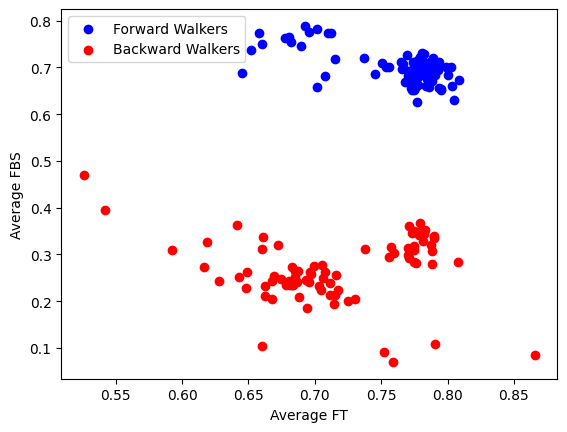

In [66]:
plt.scatter(avg_vals_forward[:,0], avg_vals_forward[:,1], color='blue', label='Forward Walkers')
plt.xlabel('Average FT')
plt.ylabel('Average FBS')
plt.scatter(avg_vals_backward[:,0], avg_vals_backward[:,1], color='red', label='Backward Walkers')
plt.legend()
plt.show()

Relatively bad backward walker 20


In [54]:
print(avg_vals_backward[20])
avg_vals_backward = np.delete(avg_vals_backward,20,0)
print(avg_vals_backward[20])

[0.76941799 0.38492308]
[0.59268017 0.30940751]


In [55]:
min_dist = 1
minidx = [0,0]
for i in range(len(avg_vals_forward)):
    for j in range(len(avg_vals_backward)):
        dist = np.linalg.norm(avg_vals_forward[i] - avg_vals_backward[j])
        if dist < min_dist:
            min_dist = dist
            minidx = [i,j]
print(min_dist,minidx)

0.2483741682568873 [68, 30]


Now comes the challenge. Designing an HP mechanism that centers both is not as simple as extending the range to fit both. I've used the closest points as a starting place, but they're still far apart. I will use an algorithm that, 

for each neuron,

determine the inclusive range that spans the range of both forward and backward walker

for every value in that range, set the minimum

scan across all maximums in that range

check which resulting range centers both the fw and bw walker's neuron the best

store the best range for comparison with subsequent slices

In [56]:
def eval_roc(traj_forward, traj_backward, n_idx, lb, ub):
    drive = np.zeros(2)
    for i in range(len(traj_forward)):
        if traj_forward[i][n_idx] < lb:
            drive[0] += -traj_forward[i][n_idx] + lb
        elif traj_forward[i][n_idx] > ub:
            drive[0] += -traj_forward[i][n_idx] + ub
        if traj_backward[i][n_idx] < lb:
            drive[1] += -traj_backward[i][n_idx] + lb
        elif traj_backward[i][n_idx] > ub:
            drive[1] += -traj_backward[i][n_idx] + ub
    drive = drive/len(traj_forward)
    return drive

In [57]:
fw_idx = 68
bw_idx = 20
res_step = 0.05

traj_forward = np.loadtxt("./Forward Walkers/%s/trajectory.dat" % fw_idx)
traj_backward = np.loadtxt("./Backward Walkers/%s/trajectory.dat" % bw_idx)

In [58]:
#use lb,ub pairs as search variables
final_ranges = np.zeros((2,2))

for neuron_idx in range(2):
    print ("Neuron %s" % neuron_idx)
    fw_max = np.max(traj_forward[:,neuron_idx])
    fw_min = np.min(traj_forward[:,neuron_idx])
    bw_max = np.max(traj_backward[:,neuron_idx])
    bw_min = np.min(traj_backward[:,neuron_idx])

    best_ranges = np.zeros((len(np.arange(min(fw_min,bw_min), max(fw_max,bw_max), res_step)),2))
    best_sum_drives = np.zeros(len(np.arange(min(fw_min,bw_min), max(fw_max,bw_max), res_step)))
    i = 0
    for lbval in np.arange(min(fw_min,bw_min), max(fw_max,bw_max), res_step):
        best_range = np.zeros(2)
        best_sum_drive = float('inf')
        for ubval in np.arange(lbval, max(fw_max,bw_max), res_step):
            drive = eval_roc(traj_forward, traj_backward, neuron_idx, lbval, ubval)
            if abs(drive).sum() < best_sum_drive:
                best_sum_drive = abs(drive).sum()
                best_range[0] = lbval
                best_range[1] = ubval
        
        best_sum_drives[i] = best_sum_drive
        best_ranges[i] = best_range

        print("lb: %s, ub: %s, sum_drive: %s" % (best_range[0], best_range[1], best_sum_drive))

        i += 1
    final_ranges[neuron_idx] = best_ranges[np.argmin(best_sum_drives)]
print(final_ranges)

Neuron 0
lb: 0.000626279, ub: 0.9506262790000001, sum_drive: 0.03994385713601688
lb: 0.050626279, ub: 0.9506262790000002, sum_drive: 0.031365802424491496
lb: 0.100626279, ub: 0.9506262790000001, sum_drive: 0.021488697805944736
lb: 0.150626279, ub: 0.9506262790000003, sum_drive: 0.011144384139717058
lb: 0.20062627900000002, ub: 0.9506262789999999, sum_drive: 0.0004887166878463562


KeyboardInterrupt: 

So what you end up getting is a tradeoff between the lowest drive and the tightest range. The question is: in context (i.e. considering the surrounding parameter space), how specific of a range do you need to exclude the nonfunctional circuits, and how precisely do you need to target walking? 

This also depends on whether you are closer to any other walkers that are actually ok and are more separable from the nonfunctional ones. We optimized for walking first then for separability, but ideally we could have had the tradeoff

In [ ]:
#use lb,range pairs as search variables 
def best_range_calc(fw_idx, bw_idx, res_step, range_limit):
    traj_forward = np.loadtxt("./Forward Walkers/%s/trajectory.dat" % fw_idx)
    traj_backward = np.loadtxt("./Backward Walkers/%s/trajectory.dat" % bw_idx)

    final_ranges = np.zeros((2,2))

    for neuron_idx in range(2):
        print ("Calculating Neuron %s..." % neuron_idx)
        
        fw_max = np.max(traj_forward[:,neuron_idx])
        fw_min = np.min(traj_forward[:,neuron_idx])
        
        bw_max = np.max(traj_backward[:,neuron_idx])
        bw_min = np.min(traj_backward[:,neuron_idx])

        best_ranges = np.zeros((len(np.arange(min(fw_min,bw_min), max(fw_max,bw_max), res_step)),2))
        best_sum_drives = np.zeros(len(np.arange(min(fw_min,bw_min), max(fw_max,bw_max), res_step)))
        i = 0
        for lbval in np.arange(min(fw_min,bw_min), max(fw_max,bw_max), res_step):
            best_range = np.zeros(2)
            best_sum_drive = float('inf')
            for rangeval in np.arange(0, min(range_limit, max(fw_max,bw_max)-lbval), res_step):
                ubval = lbval + rangeval
                drive = eval_roc(traj_forward, traj_backward, neuron_idx, lbval, ubval)
                if abs(drive).sum() < best_sum_drive:
                    best_sum_drive = abs(drive).sum()
                    best_range[0] = lbval
                    best_range[1] = ubval
            
            best_sum_drives[i] = best_sum_drive
            best_ranges[i] = best_range

            # print("lb: %s, ub: %s, sum_drive: %s" % (best_range[0], best_range[1], best_sum_drive))

            i += 1
        final_ranges[neuron_idx] = best_ranges[np.argmin(best_sum_drives)]
    print("Best Ranges: ",final_ranges)
    print("N1 drive: " , eval_roc(traj_forward, traj_backward, 0, final_ranges[0][0], final_ranges[0][1]))
    print("N2 drive: " , eval_roc(traj_forward, traj_backward, 1, final_ranges[1][0], final_ranges[1][1]))
    return final_ranges

In [ ]:
res_step = 0.025
range_limit = 0.5 #(Can artificially limit ranges if want)

for fw_idx in range(len(avg_vals_forward)):
    # for bw_idx in range(len(avg_vals_backward)):
    for bw_idx in [38]:
        print("FW idx: %s, BW idx: %s" % (fw_idx, bw_idx))
        final_ranges = best_range_calc(fw_idx, bw_idx, res_step, range_limit)

FW idx: 0, BW idx: 38
Calculating Neuron 0...
Calculating Neuron 1...
Best Ranges:  [[0.67603991 0.82603991]
 [0.2901584  0.7651584 ]]
N1 drive:  [ 0.00025462 -0.0003957 ]
N2 drive:  [-0.05700239  0.07822026]
FW idx: 1, BW idx: 38
Calculating Neuron 0...
Calculating Neuron 1...
Best Ranges:  [[0.57603991 0.85103991]
 [0.2126802  0.6876802 ]]
N1 drive:  [ 0.00082513 -0.0018807 ]
N2 drive:  [-0.11522659  0.00726508]
FW idx: 2, BW idx: 38
Calculating Neuron 0...
Calculating Neuron 1...
Best Ranges:  [[0.40103991 0.87603991]
 [0.40094759 0.87594759]]
N1 drive:  [ 0.03314573 -0.01773705]
N2 drive:  [-0.01249049  0.17986283]
FW idx: 3, BW idx: 38
Calculating Neuron 0...
Calculating Neuron 1...
Best Ranges:  [[0.67603991 0.82603991]
 [0.25335463 0.72835463]]
N1 drive:  [ 0.00055583 -0.0003957 ]
N2 drive:  [-0.05735929  0.04432537]
FW idx: 4, BW idx: 38
Calculating Neuron 0...
Calculating Neuron 1...
Best Ranges:  [[0.45103991 0.87603991]
 [0.30946069 0.78446069]]
N1 drive:  [-0.00022609 -0.00

KeyboardInterrupt: 

It seems like proximity of native averages is not so important, and that when you consider nonzero ranges, you can get much better agreement among seemingly more dissimilar patterns. This makes sense. It's like all bets are off. You can essentially just weight different parts of your cycle differently or discount them altogether. 

In [ ]:
fw_idx = 3
bw_idx = 38
final_ranges = best_range_calc(fw_idx, bw_idx, res_step, range_limit)

Calculating Neuron 0...
Calculating Neuron 1...
Best Ranges:  [[0.67603991 0.82603991]
 [0.2901584  0.7651584 ]]
N1 drive:  [ 0.00025462 -0.0003957 ]
N2 drive:  [-0.05700239  0.07822026]


In [ ]:

print(-(0.67603991 -0.82603991))
print(-(0.25335463 -0.72835463))

0.15000000000000002
0.475


fitness of fw0 = .55
fitness of bw38 = -.55

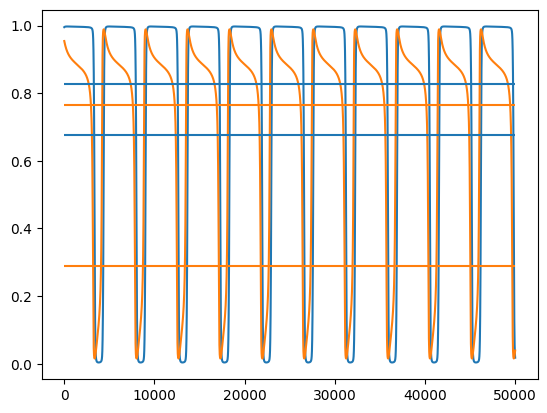

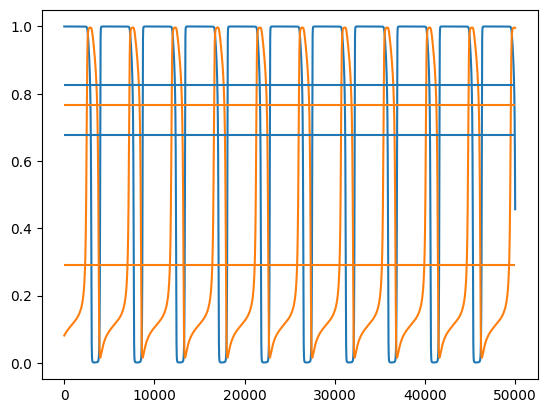

In [ ]:
traj_forward = np.loadtxt("./Forward Walkers/%s/trajectory.dat" % fw_idx)
traj_backward = np.loadtxt("./Backward Walkers/%s/trajectory.dat" % bw_idx)
plt.plot(traj_forward[:,0], label='N1')
plt.plot(traj_forward[:,1], label='N2')
plt.hlines(final_ranges[0][0], 0, len(traj_forward[:,0]), color='tab:blue', label='N1 LB')
plt.hlines(final_ranges[0][1], 0, len(traj_forward[:,0]), color='tab:blue', label='N1 UB')
plt.hlines(final_ranges[1][0], 0, len(traj_forward[:,0]), color='tab:orange', label='N2 LB ')  
plt.hlines(final_ranges[1][1], 0, len(traj_forward[:,0]), color='tab:orange', label='N2 UB')  
plt.show()
plt.plot(traj_backward[:,0], label='N1')
plt.plot(traj_backward[:,1], label='N2')
plt.hlines(final_ranges[0][0], 0, len(traj_backward[:,0]), color='tab:blue', label='N1 LB')
plt.hlines(final_ranges[0][1], 0, len(traj_backward[:,0]), color='tab:blue', label='N1 UB')
plt.hlines(final_ranges[1][0], 0, len(traj_backward[:,0]), color='tab:orange', label='N2 LB ')  
plt.hlines(final_ranges[1][1], 0, len(traj_backward[:,0]), color='tab:orange', label='N2 UB')  
plt.show()

You can definitely get pretty good with the foot neuron in these two, but the force neuron is too different. That makes sense. The foot neuron should just be down for whichever phase is long (according to the physics). But the force neuron should either be high during the long phase or low during the long phase, depending on direction. The only way to truly equalize them is to make the stance and swing phases the same length, or make one less strong for longer and one strong for shorter, with only the phase difference to the foot changing between gaits. But this would necessarily be sub-optimal. 

I bet we could get different results with a walker that was really kinda bad at both gaits, but just swapped between in-phase and out-of-phase

interestingly, the ones that seem to do okay with generalization are those that "lead" with the force neuron instead of the better strategy which is to lead with the foot neuron. This means that the force isn't sustainted at max for as long

So now, the move would be to actually implement ADHP with those ranges on fw and bw walkers *separately* and see if the steady state results are still walkers. It works sometimes. Unpredictably based on the smallest drives (which I assume are bc of inseparable/mixed performance attractors). But one solution I found is forward #3, backward #38 with lbs: 0.67604 0.253355, ubs: 0.82604 0.728355

So now now, the move is to implement this whole thing as a flexible walker. Let's quickly calculate the neuromodulatory vector between fw3 and bw38

In [61]:
with open(f'./Forward Walkers/{3}/evol.dat') as f:
        lines=f.readlines()
        phenotype = lines[-1]
        fw_phenotype = np.array(phenotype.split(), dtype=float)
with open(f'./Backward Walkers/{38}/evol.dat') as f:
        lines=f.readlines()
        phenotype = lines[-1]
        bw_phenotype = np.array(phenotype.split(), dtype=float)

In [64]:
print("Neuromodulation Vector: \n", bw_phenotype-fw_phenotype)

Neuromodulation Vector: 
 [ -1.068822  -0.35604    4.970148  -4.72709    2.93711    8.44748
 -13.83896   -0.23656 ]


In [4]:
#more precise calculation of the correct bounds
lbs_tested = np.arange(0.025,0.975,0.025)
bw_fitnesses = np.loadtxt('./Backward Walkers/fitnesses.dat')
fw_fitnesses = np.loadtxt('./Forward Walkers/fitnesses.dat')
n_labels = ['FT', 'FBS']

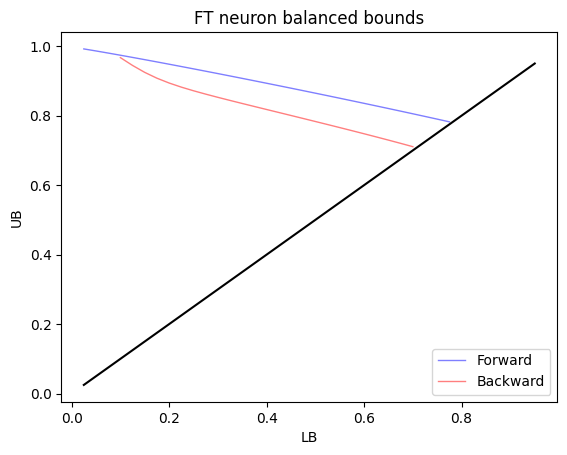

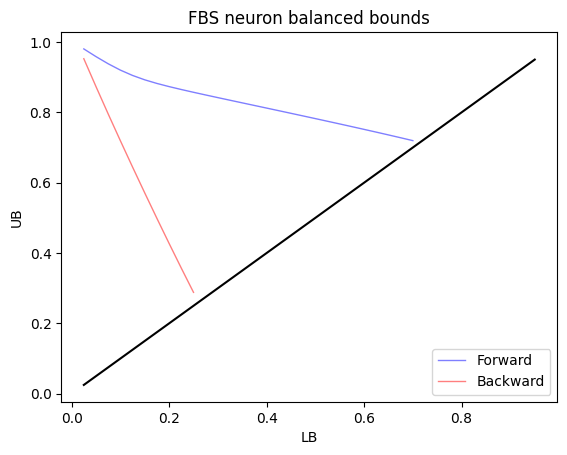

In [7]:
for n in range(2):
    for i in range(1):
        if (fw_fitnesses[i]>.5):
            fwbounds = np.loadtxt('./Forward Walkers/%s/calculatedubs.dat'%i)[n]
            plt.plot(lbs_tested[np.where(fwbounds!=0)],fwbounds[np.where(fwbounds!=0)],color='b',alpha=.5,linewidth=1,label="Forward")
        if (bw_fitnesses[i]>.5):
            bwbounds = np.loadtxt('./Backward Walkers/%s/calculatedubs.dat'%i)[n]
            plt.plot(lbs_tested[np.where(bwbounds!=0)],bwbounds[np.where(bwbounds!=0)],color='r',alpha=.5,linewidth=1,label="Backward")

    plt.plot(lbs_tested,lbs_tested,color='k')
    plt.xlabel("LB")
    plt.ylabel("UB")
    plt.legend() 
    plt.title("%s neuron balanced bounds"%n_labels[n])
    plt.show()

In [33]:
13*0.025

0.325

In [60]:
print(fw_fitnesses)

[0.55239 0.54946 0.54754 0.54973 0.54753 0.55014 0.55009 0.53095 0.55029
 0.5491  0.55169 0.56286 0.52107 0.54604 0.55687 0.55036 0.54124 0.54936
 0.55025 0.53673 0.54473 0.5558  0.56039 0.56584 0.55268 0.55436 0.54363
 0.55253 0.55532 0.54934 0.54893 0.53803 0.56012 0.54978 0.55622 0.5325
 0.55158 0.55332 0.5562  0.55593 0.52397 0.54733 0.45939 0.5471  0.55311
 0.55062 0.05544 0.5573  0.54243 0.05782 0.54928 0.53478 0.55003 0.55109
 0.549   0.55451 0.55402 0.55244 0.55211 0.55511 0.50032 0.53037 0.54079
 0.55618 0.56742 0.5572  0.55568 0.55811 0.54796 0.54197 0.05527 0.51023
 0.55361 0.54184 0.54514 0.55685 0.55341 0.5631  0.54986 0.55054 0.55207
 0.55403 0.53686 0.5553  0.55684 0.54787 0.48474 0.55522 0.54808 0.54984
 0.53624 0.53344 0.54019 0.54591 0.55426 0.53544 0.55493 0.55726 0.54774
 0.54914]


In [50]:
#find intersections
good_fw = np.where(fw_fitnesses > .5)[0]
good_bw = np.where(bw_fitnesses > .5)[0]

intersections = []

for i in good_fw:
    fwbounds = np.loadtxt('./Forward Walkers/%s/calculatedubs.dat'%i)[1]
    for j in good_bw:
        if i!=j:
            bwbounds = np.loadtxt('./Backward Walkers/%s/calculatedubs.dat'%j)[1]
            diff = np.abs(fwbounds-bwbounds)
            diff = diff[np.where(diff!=0)]
            if np.min(diff)<0.05:
                intersection = np.where(diff==np.min(diff))[0][0]
                intersections.append(intersection)
                if(intersection>4):
                    print(i,j,(intersection+1)*0.025,fwbounds[intersection],np.min(diff))


20 26 0.15000000000000002 0.843922 0.016423999999999994
20 48 0.15000000000000002 0.843922 0.012972999999999901
20 67 0.15000000000000002 0.843922 0.010014999999999996
69 67 0.15000000000000002 0.854086 0.020179000000000058
95 67 0.15000000000000002 0.856656 0.02274900000000002


In [59]:
0.843922-.15

0.6939219999999999

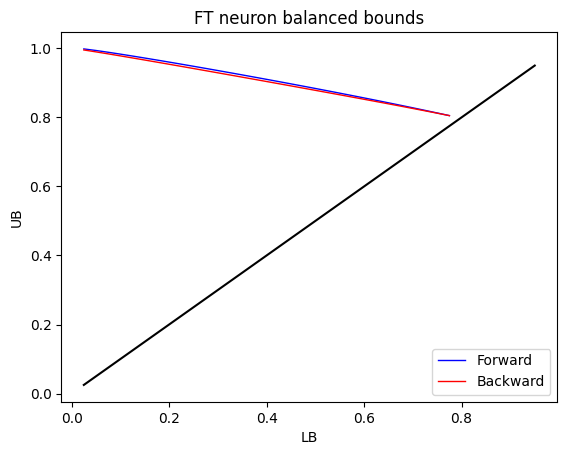

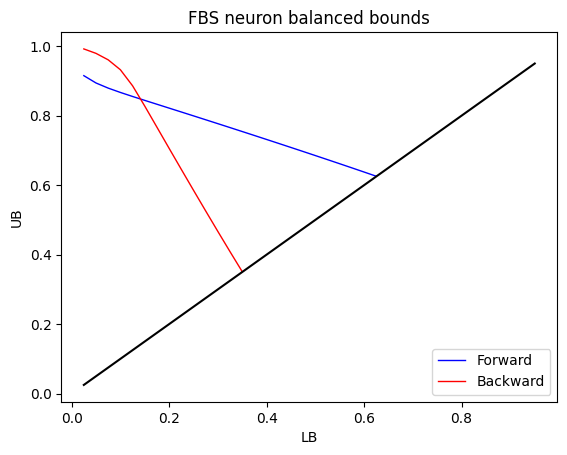

In [10]:
for n in range(2):
    for i in [20]:
        fwbounds = np.loadtxt('./Forward Walkers/%s/calculatedubs.dat'%i)[n]
        # print(fwbounds)
        for j in [26]:
            if i!=j:
                bwbounds = np.loadtxt('./Backward Walkers/%s/calculatedubs.dat'%j)[n]
                # print(bwbounds)
                plt.plot(lbs_tested[np.where(fwbounds > 0)],fwbounds[np.where(fwbounds > 0)],color='b',alpha=1,linewidth=1,label="Forward")
                plt.plot(lbs_tested[np.where(bwbounds > 0)],bwbounds[np.where(bwbounds > 0)],color='r',alpha=1,linewidth=1,label="Backward")
                # diff = np.abs(fwbounds-bwbounds)
                # diff = diff[np.where(diff!=0)]
                # intersection = np.where(diff==np.min(diff))[0][0]
                # intersections.append(intersection)
                # print(intersection,diff)
    plt.plot(lbs_tested,lbs_tested,color='k')
    plt.xlabel("LB")
    plt.ylabel("UB")
    plt.legend() 
    plt.title("%s neuron balanced bounds"%n_labels[n])
    plt.show()

In [70]:
0.885929-.125
0.812677 - .75

0.06267699999999998

In [58]:
#calc new neuromod vectors
paramsfw20 = np.array([1.75782, 1.42549,-5.54231, -2.56905,7.1776 ,-3.96608,8.43738 ,9.64775])
paramsbw26 = np.array([0.986189, 0.947394, -0.300811, -7.03552, 10 ,3.89064 ,-7.08411, 9.81925])

print(paramsbw26-paramsfw20)

[ -0.771631  -0.478096   5.241499  -4.46647    2.8224     7.85672
 -15.52149    0.1715  ]


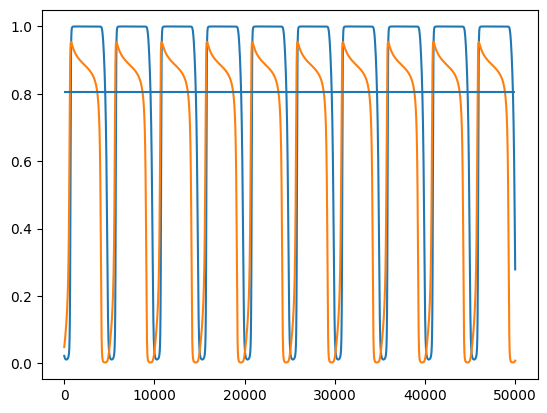

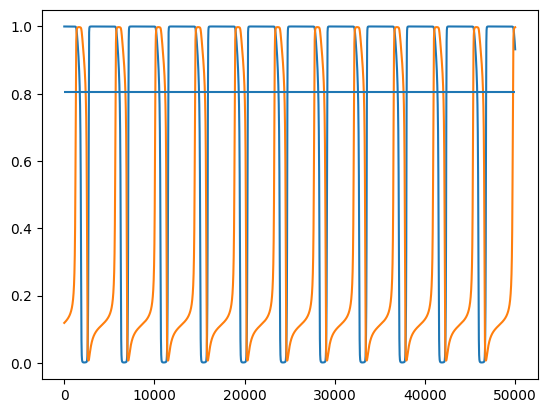

In [64]:
timeseries = np.loadtxt('./Forward Walkers/20/trajectory.dat')
plt.plot(timeseries)
plt.hlines([.805],0,50000)
plt.show()
timeseries = np.loadtxt('./Backward Walkers/26/trajectory.dat')
plt.plot(timeseries)
plt.hlines([.805],0,50000)
plt.show()

As we can see, there are many different pairs that have lines that cross, in some cases quite close to the identity line, where range is almost zero

Now, I will try to run the full agent specified by the base state of fw_3, the neuromodulation vector 

-1.068822  -0.35604    4.970148  -4.72709    2.93711    8.44748 -13.83896   -0.23656 

And the ADHP mechanism with ranges

0.67604 0.253355 0.82604 0.728355

I know that, separately started from the initial forward and backward walkers, ADHP will bring them to -4.69673 -2.3375 for forward and -0.248114 -7.09366 for backward. The question is whether those points are within the correct basin of attraction for the oppposite walker. And i guess whether the entire path is within the basin, if timing is going to be unpredictable. 

If this proves successful, I could gather data on the number of circuit pairs for which this method (pick two, numerically derive which ADHPs might work for both of them, test whether they do work, test whether works in context) works and when it breaks down and why. Ultimately I don't think that in itself would be interesting, but it would set out the space of possibilities for more rigorous exploration of why. 

I still think there's a more rigorous way to find ADHP that mathematically works for any two circuits. Or at least do it more precisely. But maybe that means that it'll be wide range and then that's pointless. But the pointlessness is the point. The problem is that the justification isn't very well circumscribed, mathematically. 

I remember my approach that what matters isn't the value of the drive that different combinations of bounds produce for a given circuit, but the set of all combinations of bounds that will produce exactly zero drive. Each lower bound (within the range of values taken on) maps onto exactly one upper bound (which will also be within the range of values taken on), or exactly one width. This produces a function across the range of possible lower bounds. Probably it's guaranteed to be continuous. Either way, there's no guarantee that two of these individual lines will cross. Or if they do it might be with huge range. But that doesn't mean the whole prospect's hopeless. Even close enough can work as long as that ADHP mechanism can find another functional rhythm nearby in each mode's domain. And this seems like something biology would take advantage of to be sloppy. Even if we pretend our evolved circuits are the best of the best, then it'd just be trading performance for regulatability. 

we could take the perfect approach and try to do the absolute BEST we can to maximize fw and bw (abstractly) while making avgs equal. Like what's the best you can possibly do with just changing the relative phase and nothing else

The ft neuron is trivially simple. No matter what phase it has to change, it could virtually always just adjust its value to compensate without any detraction in performance since it only depends on the threshold of 0.5. We could always come up with AHDP ranges that work for some version of the foot neuron in both fw and bw modes.

it's the force neuron that's the issue. Ironically, if there were two neurons (FS/BS) instead of one (FBS), there would maybe be more degeneracy and wiggle room that maybe things could be traded off sufficiently to change modes without changing the neural averages. Again, obviously not for the "ideal walkers"

And maybe that's the point. There is no way to be ideal and still be robust. Optimal is such a small point of the space to target, and biology shouldn't want to anyway. It might be too specialized to allow other modes to be maintained by the same ADHP mechanism. 

Current problem: debug and increase confidence in the flexwalk program. If no problems, then figure out why example is failing when it worked for individual circuits. First try to start running adhp from the stablized position in the opposite regime. Aligns? LTLCs? 

Note also that backwards walking was "harder" than forwards because forward can take advantage of the snapback. Now, I've corrected for this asymmetry

Another possibility is to use the sliding window. Remember I surmised that it would tweak the separability because it slightly affects oscillatory dynamics but not stationary ones. 